Data source import complete.
Using device: cuda
Train: 4535 images, Val: 825 images
Loaded 4535 samples with 67 classes
Loaded 825 samples with 67 classes
Loaded 1340 samples with 67 classes


/tmp/ipykernel_35/4216702331.py:234: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Starting enhanced training...


Epoch 1/3:   0%|          | 0/284 [00:00<?, ?it/s]/tmp/ipykernel_35/4216702331.py:279: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/3:   1%|▏         | 4/284 [00:01<01:45,  2.66it/s, Loss=8.6438, Acc=1.56%]/tmp/ipykernel_35/4216702331.py:255: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/3: 100%|██████████| 284/284 [01:44<00:00,  2.73it/s, Loss=6.4376, Acc=1.36%]
/tmp/ipykernel_35/4216702331.py:321: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/3] - Train Acc: 0.0136, Loss: 6.4376 | Val Acc: 0.0218, Loss: 4.2792 | LR: 0.000098
New best model saved with val acc: 0.0218


...

Epoch [3/3] - Train Acc: 0.0180, Loss: 6.3246 | Val Acc: 0.0327, Loss: 4.3671 | LR: 0.000080
New best model saved with val acc: 0.0327
Loaded best model from epoch 2 with val acc: 0.0327


Evaluating: 100%|██████████| 42/42 [00:14<00:00,  2.88it/s]


Test Accuracy with TTA: 0.0179 (1.79%)


Evaluating: 100%|██████████| 42/42 [00:13<00:00,  3.05it/s]


Test Accuracy without TTA: 0.0179 (1.79%)

Detailed Classification Report:
                     precision    recall  f1-score   support

     airport_inside     0.0000    0.0000    0.0000        20
          artstudio     0.0000    0.0000    0.0000        20
         auditorium     0.0526    0.0556    0.0541        18
             bakery     0.0000    0.0000    0.0000        19
                bar     0.0000    0.0000    0.0000        18
           bathroom     0.0640    0.4444    0.1119        18
            bedroom     0.0000    0.0000    0.0000        21
          bookstore     0.0000    0.0000    0.0000        20
            bowling     0.0000    0.0000    0.0000        20
             buffet     0.0093    0.1000    0.0169        20
             casino     0.0260    0.2632    0.0474        19
      children_room     0.0000    0.0000    0.0000        18
      church_inside     0.0000    0.0000    0.0000        19
          classroom     0.0000    0.0000    0.0000        18
         

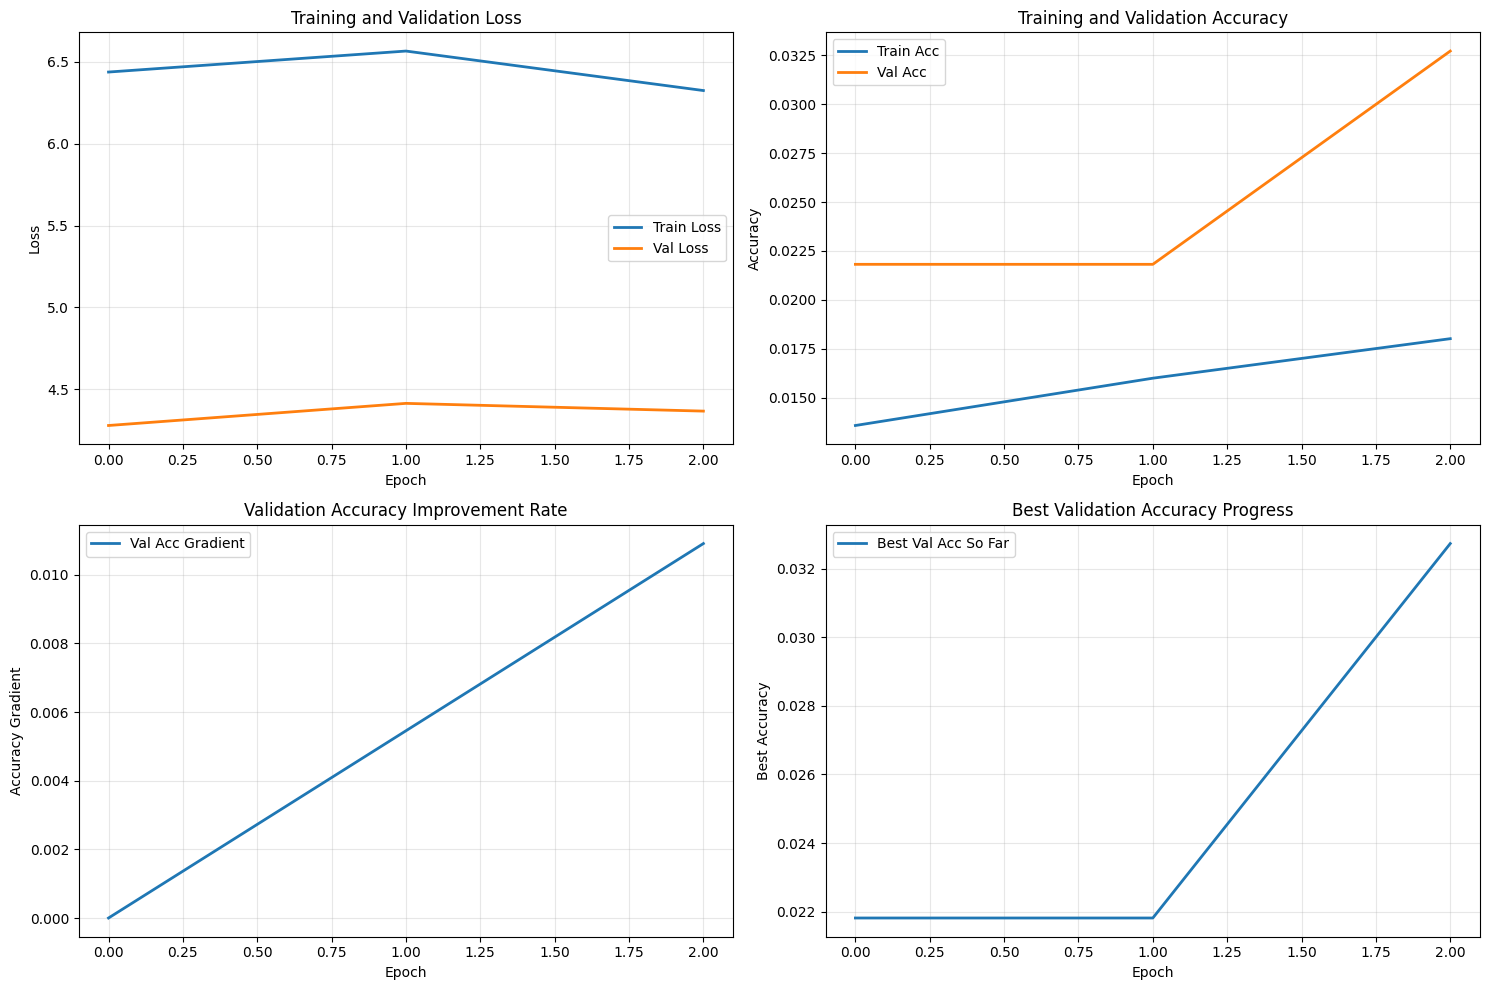


Final Results:
Best validation accuracy: 0.0327 (3.27%)
Test accuracy (no TTA): 0.0179 (1.79%)
Test accuracy (with TTA): 0.0179 (1.79%)
Improvement with TTA: 0.00%


In [5]:
# import kagglehub
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchvision import datasets, transforms, models
# import time
# import matplotlib.pyplot as plt
# import os
# from tqdm import tqdm
# from PIL import Image
# from torch.utils.data import Dataset, DataLoader
# from collections import defaultdict
# import random
# import numpy as np
# from sklearn.metrics import classification_report, confusion_matrix
# import torch.nn.functional as F

# # Set seeds for reproducibility
# torch.manual_seed(42)
# np.random.seed(42)
# random.seed(42)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(42)

# # Download dataset
# itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
# print('Data source import complete.')

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)

# # Setup paths
# basePath = itsahmad_indoor_scenes_cvpr_2019_path
# imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
# trainLabelFile = os.path.join(basePath, "TrainImages.txt")
# testLabelFile = os.path.join(basePath, "TestImages.txt")

# # Enhanced train/validation split with stratification
# def create_train_val_split(train_file, val_ratio=0.15):  # Reduced val ratio for more training data
#     """Create a stratified train/validation split"""
#     with open(train_file, 'r') as f:
#         train_lines = f.read().splitlines()
    
#     class_to_images = defaultdict(list)
#     for line in train_lines:
#         if line.strip():
#             class_name = line.split('/')[0]
#             class_to_images[class_name].append(line)
    
#     train_list, val_list = [], []
#     for cls, images in class_to_images.items():
#         random.shuffle(images)
#         split_idx = max(1, int((1 - val_ratio) * len(images)))  # Ensure at least 1 image per class in val
#         train_list += images[:split_idx]
#         val_list += images[split_idx:]
    
#     return train_list, val_list

# # Create proper split
# train_list, val_list = create_train_val_split(trainLabelFile, val_ratio=0.15)
# print(f"Train: {len(train_list)} images, Val: {len(val_list)} images")

# class Indoor67Dataset(Dataset):
#     def __init__(self, imgDir, image_list, transform=None):
#         self.samples = []
#         self.transform = transform
        
#         for imgName in image_list:
#             if imgName.strip():
#                 label = imgName.split('/')[0]
#                 fullPath = os.path.join(imgDir, imgName)
#                 if os.path.isfile(fullPath):
#                     self.samples.append((fullPath, label))
        
#         self.classes = sorted(set(lbl for _, lbl in self.samples))
#         self.classToIdx = {cls: i for i, cls in enumerate(self.classes)}
#         print(f"Loaded {len(self.samples)} samples with {len(self.classes)} classes")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         path, label = self.samples[idx]
#         try:
#             image = Image.open(path).convert("RGB")
#             if self.transform:
#                 image = self.transform(image)
#             return image, self.classToIdx[label]
#         except Exception as e:
#             print(f"Error loading image {path}: {e}")
#             # Return a dummy image if loading fails
#             dummy_image = torch.zeros(3, 224, 224)
#             return dummy_image, self.classToIdx[label]

# # Enhanced data augmentation
# trainTransform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.8, 1.2)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(20),
#     transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
#     transforms.RandomApply([transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))], p=0.3),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3))  # Cutout augmentation
# ])

# # Test Time Augmentation transforms
# valTransform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# testTransform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# # Create datasets
# trainDataset = Indoor67Dataset(imgDir, train_list, transform=trainTransform)
# valDataset = Indoor67Dataset(imgDir, val_list, transform=valTransform)

# # For test, read from file
# with open(testLabelFile, 'r') as f:
#     test_list = f.read().splitlines()
# testDataset = Indoor67Dataset(imgDir, test_list, transform=testTransform)

# # Optimized data loading
# trainLoader = DataLoader(trainDataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
# valLoader = DataLoader(valDataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
# testLoader = DataLoader(testDataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# # Enhanced model with multiple architectures ensemble capability
# class EnhancedModel(nn.Module):
#     def __init__(self, num_classes, model_name='efficientnet_b3'):
#         super(EnhancedModel, self).__init__()
        
#         if model_name == 'efficientnet_b3':
#             self.backbone = models.efficientnet_b3(weights=None)
#             # models.EfficientNet_B3_Weights.DEFAULT
#             num_features = self.backbone.classifier[1].in_features
#             self.backbone.classifier = nn.Identity()
#         elif model_name == 'resnet152':
#             self.backbone = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
#             num_features = self.backbone.fc.in_features
#             self.backbone.fc = nn.Identity()
#         else:  # default resnet50
#             self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#             num_features = self.backbone.fc.in_features
#             self.backbone.fc = nn.Identity()
        
#         # Enhanced classifier with multiple dropout layers
#         self.classifier = nn.Sequential(
#             nn.BatchNorm1d(num_features),
#             nn.Dropout(0.5),
#             nn.Linear(num_features, 512),
#             nn.ReLU(inplace=True),
#             nn.BatchNorm1d(512),
#             nn.Dropout(0.3),
#             nn.Linear(512, 256),
#             nn.ReLU(inplace=True),
#             nn.BatchNorm1d(256),
#             nn.Dropout(0.2),
#             nn.Linear(256, num_classes)
#         )
        
#     def forward(self, x):
#         features = self.backbone(x)
#         return self.classifier(features)

# # Try EfficientNet-B3 for better performance
# model = EnhancedModel(len(trainDataset.classes), model_name='efficientnet_b3')
# model = model.to(device)
# model = torch.compile(model)

# # Enhanced loss with focal loss for handling class imbalance
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=1, gamma=2, label_smoothing=0.1):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.label_smoothing = label_smoothing
        
#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, label_smoothing=self.label_smoothing, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
#         return focal_loss.mean()

# criterion = FocalLoss(alpha=1, gamma=2, label_smoothing=0.1)

# # Advanced optimizer with different learning rates for backbone and classifier
# backbone_params = list(model.backbone.parameters())
# classifier_params = list(model.classifier.parameters())

# # optimizer = optim.AdamW([
# #     {'params': backbone_params, 'lr': 0.0001},  # Lower LR for pretrained backbone
# #     {'params': classifier_params, 'lr': 0.001}  # Higher LR for new classifier
# # ], weight_decay=0.01)

# optimizer = optim.AdamW([
#     {'params': backbone_params, 'lr': 0.001},     # used to be 0.0001
#     {'params': classifier_params, 'lr': 0.005}     # used to be 0.001
# ], weight_decay=0.01)

# # Cosine annealing with warm restarts
# # scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
# #     optimizer, T_0=10, T_mult=2, eta_min=1e-6
# # )

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# # Mixup augmentation
# def mixup_data(x, y, alpha=0.2):
#     if alpha > 0:
#         lam = np.random.beta(alpha, alpha)
#     else:
#         lam = 1
    
#     batch_size = x.size(0)
#     index = torch.randperm(batch_size).to(x.device)
    
#     mixed_x = lam * x + (1 - lam) * x[index, :]
#     y_a, y_b = y, y[index]
#     return mixed_x, y_a, y_b, lam

# def mixup_criterion(criterion, pred, y_a, y_b, lam):
#     return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# def train_model(model, train_loader, val_loader, num_epochs=80, patience=15):
#     train_losses, train_accs, val_losses, val_accs = [], [], [], []
#     best_val_acc = 0.0
#     patience_counter = 0
    
#     # Gradient scaler for mixed precision training
#     scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
#     for epoch in range(num_epochs):
#         # Training phase
#         model.train()
#         running_loss = 0.0
#         correct = 0
#         total = 0
        
#         progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
#         for batch_idx, (images, labels) in enumerate(progress_bar):
#             images, labels = images.to(device), labels.to(device)
            
#             # Apply mixup with probability 0.5
#             if random.random() > 0.5:
#                 images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
                
#                 optimizer.zero_grad()
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
#                     scaler.scale(loss).backward()
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                 else:
#                     outputs = model(images)
#                     loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     optimizer.step()
                
#                 # For accuracy calculation with mixup
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += labels.size(0)
#                 correct += (lam * predicted.eq(labels_a).sum().float() + 
#                            (1 - lam) * predicted.eq(labels_b).sum().float()).item()
#             else:
#                 optimizer.zero_grad()
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = criterion(outputs, labels)
#                     scaler.scale(loss).backward()
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels)
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     optimizer.step()
                
#                 running_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()
            
#             running_loss += loss.item()
#             progress_bar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 
#                                     'Acc': f'{100.*correct/total:.2f}%'})
        
#         scheduler.step()
        
#         train_acc = correct / total
#         train_loss = running_loss / len(train_loader)
#         train_accs.append(train_acc)
#         train_losses.append(train_loss)
        
#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_correct = 0
#         val_total = 0
        
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = criterion(outputs, labels)
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels)
                
#                 val_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 val_total += labels.size(0)
#                 val_correct += (predicted == labels).sum().item()
        
#         val_acc = val_correct / val_total
#         val_loss = val_loss / len(val_loader)
#         val_accs.append(val_acc)
#         val_losses.append(val_loss)
        
#         print(f'Epoch [{epoch+1}/{num_epochs}] - '
#               f'Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | '
#               f'Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | '
#               f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
#         # Early stopping with model saving
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             patience_counter = 0
#             torch.save({
#                 'model_state_dict': model.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 'val_acc': val_acc,
#                 'epoch': epoch
#             }, 'best_model_enhanced.pth')
#             print(f"New best model saved with val acc: {val_acc:.4f}")
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 print(f"Early stopping at epoch {epoch+1}")
#                 break
    
#     return train_losses, train_accs, val_losses, val_accs

# # Test Time Augmentation
# def test_time_augmentation(model, image, num_augmentations=5):
#     """Apply test time augmentation for better predictions"""
#     augment_transforms = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((256, 256)),
#         transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#         transforms.RandomHorizontalFlip(p=0.5),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])
    
#     predictions = []
    
#     # Original prediction
#     with torch.no_grad():
#         pred = model(image.unsqueeze(0))
#         predictions.append(F.softmax(pred, dim=1))
    
#     # Augmented predictions
#     for _ in range(num_augmentations):
#         # Convert back to PIL for augmentation
#         pil_image = transforms.ToPILImage()(image.cpu())
#         aug_image = augment_transforms(pil_image).to(device)
        
#         with torch.no_grad():
#             pred = model(aug_image.unsqueeze(0))
#             predictions.append(F.softmax(pred, dim=1))
    
#     # Average all predictions
#     avg_pred = torch.mean(torch.stack(predictions), dim=0)
#     return avg_pred

# # Enhanced evaluation with TTA
# def evaluate_model_with_tta(model, test_loader, use_tta=True):
#     model.eval()
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_labels = []
    
#     with torch.no_grad():
#         for images, labels in tqdm(test_loader, desc="Evaluating"):
#             images, labels = images.to(device), labels.to(device)
            
#             if use_tta and images.size(0) == 1:  # TTA for single images
#                 outputs = test_time_augmentation(model, images[0])
#             else:
#                 outputs = model(images)
#                 outputs = F.softmax(outputs, dim=1)
            
#             _, predicted = torch.max(outputs, 1)
            
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
            
#             all_predictions.extend(predicted.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
    
#     accuracy = correct / total
#     return accuracy, all_predictions, all_labels

# print("Starting enhanced training...")
# train_losses, train_accs, val_losses, val_accs = train_model(
#     model, trainLoader, valLoader, num_epochs=3, patience=20
# )

# # Load best model for testing
# checkpoint = torch.load('best_model_enhanced.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# print(f"Loaded best model from epoch {checkpoint['epoch']} with val acc: {checkpoint['val_acc']:.4f}")

# # Enhanced evaluation
# test_accuracy, predictions, true_labels = evaluate_model_with_tta(model, testLoader, use_tta=True)
# print(f'Test Accuracy with TTA: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# # Regular evaluation without TTA for comparison
# test_accuracy_no_tta, _, _ = evaluate_model_with_tta(model, testLoader, use_tta=False)
# print(f'Test Accuracy without TTA: {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)')

# # Detailed classification report
# class_names = testDataset.classes
# print("\nDetailed Classification Report:")
# print(classification_report(true_labels, predictions, target_names=class_names, digits=4, zero_division=0))

# # Plot enhanced training history
# plt.figure(figsize=(15, 10))

# plt.subplot(2, 2, 1)
# plt.plot(train_losses, label='Train Loss', linewidth=2)
# plt.plot(val_losses, label='Val Loss', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.title('Training and Validation Loss')
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 2)
# plt.plot(train_accs, label='Train Acc', linewidth=2)
# plt.plot(val_accs, label='Val Acc', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.title('Training and Validation Accuracy')
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 3)
# if len(val_accs) > 2:  # Need at least 3 points for gradient
#     plt.plot(np.gradient(val_accs), label='Val Acc Gradient', linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy Gradient')
#     plt.legend()
#     plt.title('Validation Accuracy Improvement Rate')
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'Not enough epochs\nfor gradient plot', 
#              ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Validation Accuracy Improvement Rate')

# plt.subplot(2, 2, 4)
# if len(val_accs) > 0:
#     epochs = range(len(val_accs))
#     plt.plot(epochs, [max(val_accs[:i+1]) for i in epochs], label='Best Val Acc So Far', linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Best Accuracy')
#     plt.legend()
#     plt.title('Best Validation Accuracy Progress')
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'No validation data\navailable', 
#              ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Best Validation Accuracy Progress')

# plt.tight_layout()
# plt.show()

# print(f"\nFinal Results:")
# print(f"Best validation accuracy: {max(val_accs):.4f} ({max(val_accs)*100:.2f}%)")
# print(f"Test accuracy (no TTA): {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)")
# print(f"Test accuracy (with TTA): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
# print(f"Improvement with TTA: {(test_accuracy - test_accuracy_no_tta)*100:.2f}%")

In [6]:
# # Full Updated Code with Hyperparameter Grid Search for EfficientNet-B3

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchvision import models
# import numpy as np
# from itertools import product
# from tqdm import tqdm

# # Assumed already available in scope:
# # - Indoor67Dataset
# # - trainDataset, valDataset
# # - train_model function (from your existing code)

# # Step 1: Hyperparameter Grid
# param_grid = {
#     'lr_backbone': [0.0001, 0.001],
#     'lr_classifier': [0.001, 0.005],
#     'dropout1': [0.3, 0.5],
#     'dropout2': [0.2, 0.4],
#     'batch_size': [16, 32]
# }

# param_combinations = list(product(*param_grid.values()))
# param_names = list(param_grid.keys())

# # Step 2: Updated EnhancedModel
# class EnhancedModel(nn.Module):
#     def __init__(self, num_classes, model_name='efficientnet_b3', dropout1=0.5, dropout2=0.3):
#         super(EnhancedModel, self).__init__()
#         if model_name == 'efficientnet_b3':
#             self.backbone = models.efficientnet_b3(weights=None)
#             num_features = self.backbone.classifier[1].in_features
#             self.backbone.classifier = nn.Identity()
#         else:
#             raise ValueError("Only efficientnet_b3 is supported.")

#         self.classifier = nn.Sequential(
#             nn.BatchNorm1d(num_features),
#             nn.Dropout(dropout1),
#             nn.Linear(num_features, 512),
#             nn.ReLU(inplace=True),
#             nn.BatchNorm1d(512),
#             nn.Dropout(dropout2),
#             nn.Linear(512, 256),
#             nn.ReLU(inplace=True),
#             nn.BatchNorm1d(256),
#             nn.Dropout(0.2),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         features = self.backbone(x)
#         return self.classifier(features)

# # Step 3: Grid Search
# results = []

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# num_classes = len(trainDataset.classes)

# for i, combo in enumerate(param_combinations):
#     combo_dict = dict(zip(param_names, combo))
#     print(f"\n\U0001F501 Running trial {i+1}/{len(param_combinations)} with params: {combo_dict}")

#     trainLoader = DataLoader(trainDataset, batch_size=combo_dict['batch_size'], shuffle=True, num_workers=0)
#     valLoader = DataLoader(valDataset, batch_size=combo_dict['batch_size'], shuffle=False, num_workers=0)

#     model = EnhancedModel(num_classes, 'efficientnet_b3', 
#                           dropout1=combo_dict['dropout1'], 
#                           dropout2=combo_dict['dropout2']).to(device)

#     optimizer = optim.AdamW([
#         {'params': model.backbone.parameters(), 'lr': combo_dict['lr_backbone']},
#         {'params': model.classifier.parameters(), 'lr': combo_dict['lr_classifier']}
#     ], weight_decay=0.01)

#     scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

#     train_losses, train_accs, val_losses, val_accs = train_model(
#         model, trainLoader, valLoader, num_epochs=10, patience=3
#     )

#     best_val_acc = max(val_accs)
#     results.append((combo_dict, best_val_acc))

# # Step 4: Print Best Results
# results = sorted(results, key=lambda x: x[1], reverse=True)
# print("\n\U00002705 Top Hyperparameter Settings:")
# for params, acc in results[:5]:
#     print(f"Val Acc: {acc:.4f} | Params: {params}")



🔁 Running trial 1/32 with params: {'lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.3, 'dropout2': 0.2, 'batch_size': 16}


/tmp/ipykernel_35/4216702331.py:234: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
Epoch 1/10:   0%|          | 0/284 [00:00<?, ?it/s]/tmp/ipykernel_35/4216702331.py:279: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10:   1%|          | 3/284 [00:01<01:57,  2.40it/s, Loss=8.8234, Acc=0.00%]/tmp/ipykernel_35/4216702331.py:255: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10: 100%|██████████| 284/284 [01:49<00:00,  2.60it/s, Loss=6.3393, Acc=1.54%]
/tmp/ipykernel_35/4216702331.py:321: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` ins

Epoch [1/10] - Train Acc: 0.0154, Loss: 6.3393 | Val Acc: 0.0145, Loss: 4.3774 | LR: 0.000100
New best model saved with val acc: 0.0145


Epoch 2/10: 100%|██████████| 284/284 [01:45<00:00,  2.69it/s, Loss=6.3723, Acc=1.47%]


Epoch [2/10] - Train Acc: 0.0147, Loss: 6.3723 | Val Acc: 0.0145, Loss: 5.1092 | LR: 0.000100


...

Epoch [8/10] - Train Acc: 0.0255, Loss: 6.0630 | Val Acc: 0.0327, Loss: 3.8902 | LR: 0.001000


Epoch 9/10: 100%|██████████| 142/142 [01:36<00:00,  1.47it/s, Loss=5.9872, Acc=2.72%]


Epoch [9/10] - Train Acc: 0.0272, Loss: 5.9872 | Val Acc: 0.0400, Loss: 3.8427 | LR: 0.001000
New best model saved with val acc: 0.0400


Epoch 10/10: 100%|██████████| 142/142 [01:36<00:00,  1.47it/s, Loss=6.0745, Acc=2.97%]


Epoch [10/10] - Train Acc: 0.0297, Loss: 6.0745 | Val Acc: 0.0364, Loss: 3.8012 | LR: 0.001000

✅ Top Hyperparameter Settings:
Val Acc: 0.0703 | Params: {'lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.5, 'dropout2': 0.4, 'batch_size': 32}
Val Acc: 0.0618 | Params: {'lr_backbone': 0.0001, 'lr_classifier': 0.005, 'dropout1': 0.5, 'dropout2': 0.2, 'batch_size': 32}
Val Acc: 0.0570 | Params: {'lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.3, 'dropout2': 0.2, 'batch_size': 16}
Val Acc: 0.0570 | Params: {'lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.3, 'dropout2': 0.2, 'batch_size': 32}
Val Acc: 0.0558 | Params: {'lr_backbone': 0.0001, 'lr_classifier': 0.005, 'dropout1': 0.3, 'dropout2': 0.4, 'batch_size': 32}


Data source import complete.
Using device: cuda
Train: 4535 images, Val: 825 images
Loaded 4535 samples with 67 classes
Loaded 825 samples with 67 classes
Loaded 1340 samples with 67 classes


/tmp/ipykernel_35/3079707747.py:243: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Starting enhanced training...


Epoch 1/100:   0%|          | 0/142 [00:00<?, ?it/s]/tmp/ipykernel_35/3079707747.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/100:   3%|▎         | 4/142 [00:06<02:14,  1.03it/s, Loss=8.5927, Acc=0.78%]/tmp/ipykernel_35/3079707747.py:264: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/100: 100%|██████████| 142/142 [00:44<00:00,  3.18it/s, Loss=6.5323, Acc=1.50%]
/tmp/ipykernel_35/3079707747.py:330: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/100] - Train Acc: 0.0150, Loss: 6.5323 | Val Acc: 0.0182, Loss: 4.1328 | LR: 0.000100
New best model saved with val acc: 0.0182


...

Epoch [86/100] - Train Acc: 0.1901, Loss: 4.4568 | Val Acc: 0.2230, Loss: 3.3377 | LR: 0.000001
Early stopping at epoch 86
Loaded best model from epoch 65 with val acc: 0.2388


Evaluating: 100%|██████████| 42/42 [00:08<00:00,  4.82it/s]


Test Accuracy with TTA: 0.2097 (20.97%)


Evaluating: 100%|██████████| 42/42 [00:05<00:00,  7.36it/s]


Test Accuracy without TTA: 0.2097 (20.97%)

Detailed Classification Report:
                     precision    recall  f1-score   support

     airport_inside     0.0000    0.0000    0.0000        20
          artstudio     0.0000    0.0000    0.0000        20
         auditorium     0.2500    0.2778    0.2632        18
             bakery     0.1429    0.1053    0.1212        19
                bar     0.0588    0.0556    0.0571        18
           bathroom     0.3500    0.3889    0.3684        18
            bedroom     0.0000    0.0000    0.0000        21
          bookstore     0.0789    0.1500    0.1034        20
            bowling     0.3103    0.4500    0.3673        20
             buffet     0.1818    0.2000    0.1905        20
             casino     0.2692    0.3684    0.3111        19
      children_room     0.0909    0.0556    0.0690        18
      church_inside     0.1957    0.4737    0.2769        19
          classroom     0.2571    0.5000    0.3396        18
        

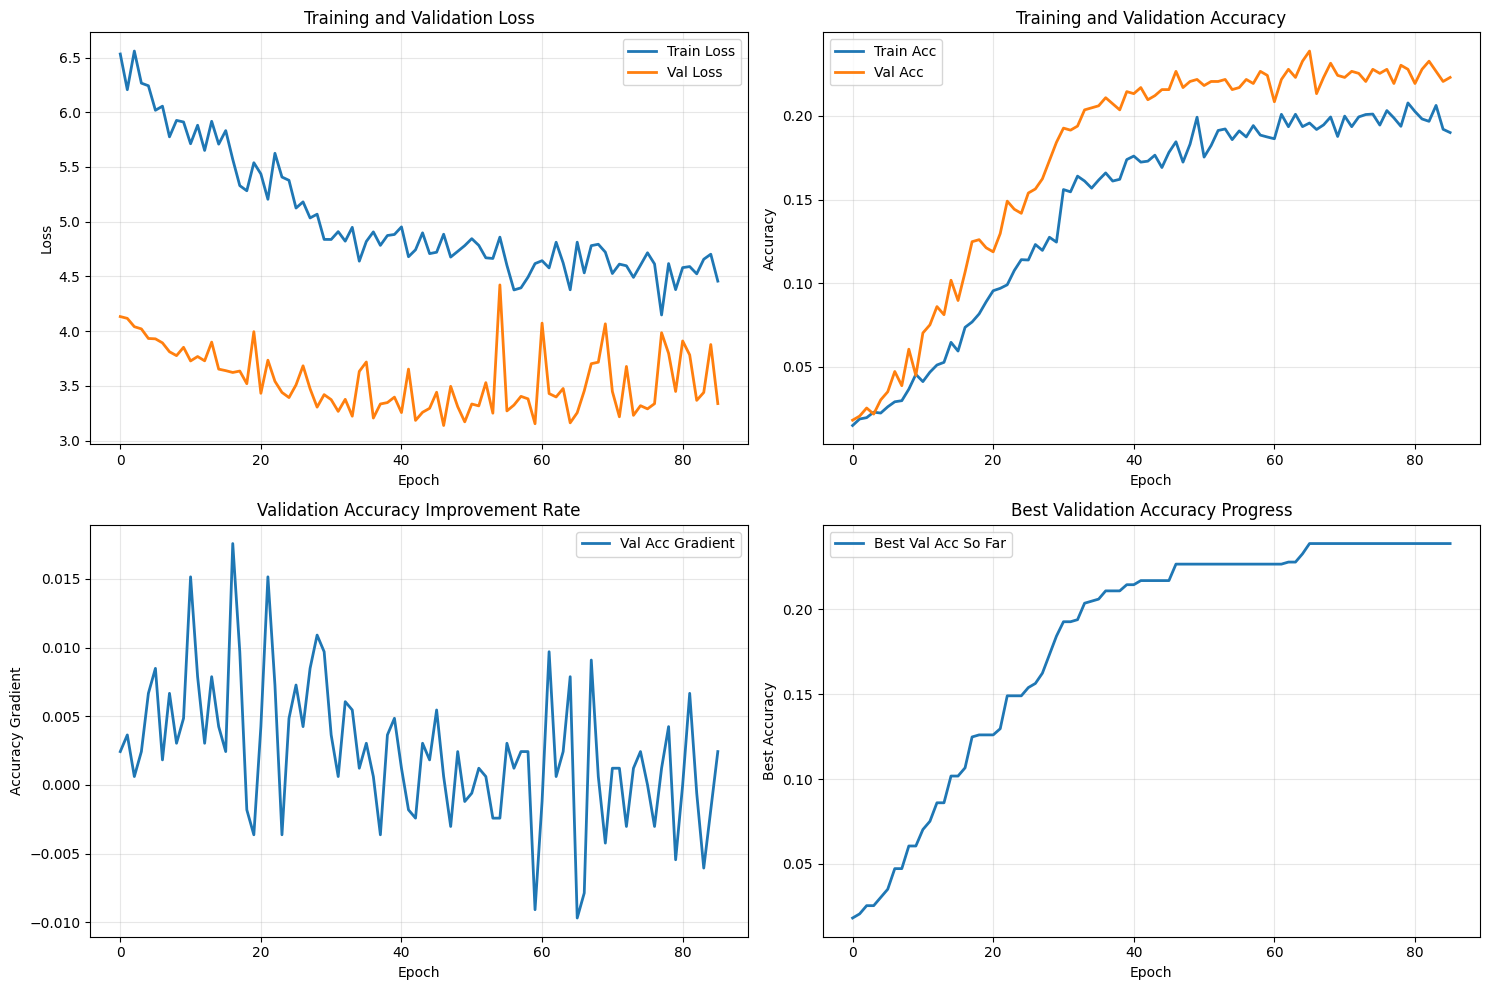


Final Results:
Best validation accuracy: 0.2388 (23.88%)
Test accuracy (no TTA): 0.2097 (20.97%)
Test accuracy (with TTA): 0.2097 (20.97%)
Improvement with TTA: 0.00%


In [1]:
# import kagglehub
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchvision import datasets, transforms, models
# import time
# import matplotlib.pyplot as plt
# import os
# from tqdm import tqdm
# from PIL import Image
# from torch.utils.data import Dataset, DataLoader
# from collections import defaultdict
# import random
# import numpy as np
# from sklearn.metrics import classification_report, confusion_matrix
# import torch.nn.functional as F

# # Set seeds for reproducibility
# torch.manual_seed(42)
# np.random.seed(42)
# random.seed(42)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(42)

# # Download dataset
# itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
# print('Data source import complete.')

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)

# # Setup paths
# basePath = itsahmad_indoor_scenes_cvpr_2019_path
# imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
# trainLabelFile = os.path.join(basePath, "TrainImages.txt")
# testLabelFile = os.path.join(basePath, "TestImages.txt")

# # Enhanced train/validation split with stratification
# def create_train_val_split(train_file, val_ratio=0.15):  # Reduced val ratio for more training data
#     """Create a stratified train/validation split"""
#     with open(train_file, 'r') as f:
#         train_lines = f.read().splitlines()
    
#     class_to_images = defaultdict(list)
#     for line in train_lines:
#         if line.strip():
#             class_name = line.split('/')[0]
#             class_to_images[class_name].append(line)
    
#     train_list, val_list = [], []
#     for cls, images in class_to_images.items():
#         random.shuffle(images)
#         split_idx = max(1, int((1 - val_ratio) * len(images)))  # Ensure at least 1 image per class in val
#         train_list += images[:split_idx]
#         val_list += images[split_idx:]
    
#     return train_list, val_list

# # Create proper split
# train_list, val_list = create_train_val_split(trainLabelFile, val_ratio=0.15)
# print(f"Train: {len(train_list)} images, Val: {len(val_list)} images")

# class Indoor67Dataset(Dataset):
#     def __init__(self, imgDir, image_list, transform=None):
#         self.samples = []
#         self.transform = transform
        
#         for imgName in image_list:
#             if imgName.strip():
#                 label = imgName.split('/')[0]
#                 fullPath = os.path.join(imgDir, imgName)
#                 if os.path.isfile(fullPath):
#                     self.samples.append((fullPath, label))
        
#         self.classes = sorted(set(lbl for _, lbl in self.samples))
#         self.classToIdx = {cls: i for i, cls in enumerate(self.classes)}
#         print(f"Loaded {len(self.samples)} samples with {len(self.classes)} classes")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         path, label = self.samples[idx]
#         try:
#             image = Image.open(path).convert("RGB")
#             if self.transform:
#                 image = self.transform(image)
#             return image, self.classToIdx[label]
#         except Exception as e:
#             print(f"Error loading image {path}: {e}")
#             # Return a dummy image if loading fails
#             dummy_image = torch.zeros(3, 224, 224)
#             return dummy_image, self.classToIdx[label]

# # Enhanced data augmentation
# trainTransform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.8, 1.2)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(20),
#     transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
#     transforms.RandomApply([transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))], p=0.3),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3))  # Cutout augmentation
# ])

# # Test Time Augmentation transforms
# valTransform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# testTransform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# # Create datasets
# trainDataset = Indoor67Dataset(imgDir, train_list, transform=trainTransform)
# valDataset = Indoor67Dataset(imgDir, val_list, transform=valTransform)

# # For test, read from file
# with open(testLabelFile, 'r') as f:
#     test_list = f.read().splitlines()
# testDataset = Indoor67Dataset(imgDir, test_list, transform=testTransform)
# # lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.5, 'dropout2': 0.4, 'batch_size': 32
# batch_size=32
# # Optimized data loading
# trainLoader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
# valLoader = DataLoader(valDataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
# testLoader = DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# # Enhanced model with multiple architectures ensemble capability
# class EnhancedModel(nn.Module):
#     def __init__(self, num_classes, model_name='efficientnet_b3'):
#         super(EnhancedModel, self).__init__()
        
#         if model_name == 'efficientnet_b3':
#             self.backbone = models.efficientnet_b3(weights=None)
#             # models.EfficientNet_B3_Weights.DEFAULT
#             num_features = self.backbone.classifier[1].in_features
#             self.backbone.classifier = nn.Identity()
#         elif model_name == 'resnet152':
#             self.backbone = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
#             num_features = self.backbone.fc.in_features
#             self.backbone.fc = nn.Identity()
#         else:  # default resnet50
#             self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#             num_features = self.backbone.fc.in_features
#             self.backbone.fc = nn.Identity()
        
#         # Enhanced classifier with multiple dropout layers
#         self.classifier = nn.Sequential(
#             nn.BatchNorm1d(num_features),
#             nn.Dropout(0.5),
#             nn.Linear(num_features, 512),
#             nn.ReLU(inplace=True),
#             nn.BatchNorm1d(512),
#             nn.Dropout(0.4),
#             nn.Linear(512, 256),
#             nn.ReLU(inplace=True),
#             nn.BatchNorm1d(256),
#             nn.Dropout(0.2),
#             nn.Linear(256, num_classes)
#         )
        
#     def forward(self, x):
#         features = self.backbone(x)
#         return self.classifier(features)

# # Try EfficientNet-B3 for better performance
# model = EnhancedModel(len(trainDataset.classes), model_name='efficientnet_b3')
# model = model.to(device)

# # Enhanced loss with focal loss for handling class imbalance
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=1, gamma=2, label_smoothing=0.1):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.label_smoothing = label_smoothing
        
#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, label_smoothing=self.label_smoothing, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
#         return focal_loss.mean()

# criterion = FocalLoss(alpha=1, gamma=2, label_smoothing=0.1)

# # Advanced optimizer with different learning rates for backbone and classifier
# backbone_params = list(model.backbone.parameters())
# classifier_params = list(model.classifier.parameters())

# # optimizer = optim.AdamW([
# #     {'params': backbone_params, 'lr': 0.0001},  # Lower LR for pretrained backbone
# #     {'params': classifier_params, 'lr': 0.001}  # Higher LR for new classifier
# # ], weight_decay=0.01)

# # lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.5, 'dropout2': 0.4, 'batch_size': 32
# optimizer = optim.AdamW([
#     {'params': backbone_params, 'lr': 0.001},     # used to be 0.0001
#     {'params': classifier_params, 'lr': 0.001}     # used to be 0.001
# ], weight_decay=0.01)

# # Cosine annealing with warm restarts
# # scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
# #     optimizer, T_0=10, T_mult=2, eta_min=1e-6
# # )

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# # Mixup augmentation
# def mixup_data(x, y, alpha=0.2):
#     if alpha > 0:
#         lam = np.random.beta(alpha, alpha)
#     else:
#         lam = 1
    
#     batch_size = x.size(0)
#     index = torch.randperm(batch_size).to(x.device)
    
#     mixed_x = lam * x + (1 - lam) * x[index, :]
#     y_a, y_b = y, y[index]
#     return mixed_x, y_a, y_b, lam

# def mixup_criterion(criterion, pred, y_a, y_b, lam):
#     return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# def train_model(model, train_loader, val_loader, num_epochs=100, patience=20):
#     train_losses, train_accs, val_losses, val_accs = [], [], [], []
#     best_val_acc = 0.0
#     patience_counter = 0
    
#     # Gradient scaler for mixed precision training
#     scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
#     for epoch in range(num_epochs):
#         # Training phase
#         model.train()
#         running_loss = 0.0
#         correct = 0
#         total = 0
        
#         progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
#         for batch_idx, (images, labels) in enumerate(progress_bar):
#             images, labels = images.to(device), labels.to(device)
            
#             # Apply mixup with probability 0.5
#             if random.random() > 0.5:
#                 images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
                
#                 optimizer.zero_grad()
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
#                     scaler.scale(loss).backward()
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                 else:
#                     outputs = model(images)
#                     loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     optimizer.step()
                
#                 # For accuracy calculation with mixup
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += labels.size(0)
#                 correct += (lam * predicted.eq(labels_a).sum().float() + 
#                            (1 - lam) * predicted.eq(labels_b).sum().float()).item()
#             else:
#                 optimizer.zero_grad()
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = criterion(outputs, labels)
#                     scaler.scale(loss).backward()
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels)
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     optimizer.step()
                
#                 running_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()
            
#             running_loss += loss.item()
#             progress_bar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 
#                                     'Acc': f'{100.*correct/total:.2f}%'})
        
#         scheduler.step()
        
#         train_acc = correct / total
#         train_loss = running_loss / len(train_loader)
#         train_accs.append(train_acc)
#         train_losses.append(train_loss)
        
#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_correct = 0
#         val_total = 0
        
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = criterion(outputs, labels)
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels)
                
#                 val_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 val_total += labels.size(0)
#                 val_correct += (predicted == labels).sum().item()
        
#         val_acc = val_correct / val_total
#         val_loss = val_loss / len(val_loader)
#         val_accs.append(val_acc)
#         val_losses.append(val_loss)
        
#         print(f'Epoch [{epoch+1}/{num_epochs}] - '
#               f'Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | '
#               f'Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | '
#               f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
#         # Early stopping with model saving
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             patience_counter = 0
#             torch.save({
#                 'model_state_dict': model.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 'val_acc': val_acc,
#                 'epoch': epoch
#             }, 'best_model_enhanced.pth')
#             print(f"New best model saved with val acc: {val_acc:.4f}")
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 print(f"Early stopping at epoch {epoch+1}")
#                 break
    
#     return train_losses, train_accs, val_losses, val_accs

# # Test Time Augmentation
# def test_time_augmentation(model, image, num_augmentations=5):
#     """Apply test time augmentation for better predictions"""
#     augment_transforms = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((256, 256)),
#         transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#         transforms.RandomHorizontalFlip(p=0.5),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])
    
#     predictions = []
    
#     # Original prediction
#     with torch.no_grad():
#         pred = model(image.unsqueeze(0))
#         predictions.append(F.softmax(pred, dim=1))
    
#     # Augmented predictions
#     for _ in range(num_augmentations):
#         # Convert back to PIL for augmentation
#         pil_image = transforms.ToPILImage()(image.cpu())
#         aug_image = augment_transforms(pil_image).to(device)
        
#         with torch.no_grad():
#             pred = model(aug_image.unsqueeze(0))
#             predictions.append(F.softmax(pred, dim=1))
    
#     # Average all predictions
#     avg_pred = torch.mean(torch.stack(predictions), dim=0)
#     return avg_pred

# # Enhanced evaluation with TTA
# def evaluate_model_with_tta(model, test_loader, use_tta=True):
#     model.eval()
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_labels = []
    
#     with torch.no_grad():
#         for images, labels in tqdm(test_loader, desc="Evaluating"):
#             images, labels = images.to(device), labels.to(device)
            
#             if use_tta and images.size(0) == 1:  # TTA for single images
#                 outputs = test_time_augmentation(model, images[0])
#             else:
#                 outputs = model(images)
#                 outputs = F.softmax(outputs, dim=1)
            
#             _, predicted = torch.max(outputs, 1)
            
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
            
#             all_predictions.extend(predicted.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
    
#     accuracy = correct / total
#     return accuracy, all_predictions, all_labels

# print("Starting enhanced training...")
# train_losses, train_accs, val_losses, val_accs = train_model(
#     model, trainLoader, valLoader, num_epochs=100, patience=20
# )

# # Load best model for testing
# checkpoint = torch.load('best_model_enhanced.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# print(f"Loaded best model from epoch {checkpoint['epoch']} with val acc: {checkpoint['val_acc']:.4f}")

# # Enhanced evaluation
# test_accuracy, predictions, true_labels = evaluate_model_with_tta(model, testLoader, use_tta=True)
# print(f'Test Accuracy with TTA: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# # Regular evaluation without TTA for comparison
# test_accuracy_no_tta, _, _ = evaluate_model_with_tta(model, testLoader, use_tta=False)
# print(f'Test Accuracy without TTA: {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)')

# # Detailed classification report
# class_names = testDataset.classes
# print("\nDetailed Classification Report:")
# print(classification_report(true_labels, predictions, target_names=class_names, digits=4, zero_division=0))

# # Plot enhanced training history
# plt.figure(figsize=(15, 10))

# plt.subplot(2, 2, 1)
# plt.plot(train_losses, label='Train Loss', linewidth=2)
# plt.plot(val_losses, label='Val Loss', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.title('Training and Validation Loss')
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 2)
# plt.plot(train_accs, label='Train Acc', linewidth=2)
# plt.plot(val_accs, label='Val Acc', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.title('Training and Validation Accuracy')
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 3)
# if len(val_accs) > 2:  # Need at least 3 points for gradient
#     plt.plot(np.gradient(val_accs), label='Val Acc Gradient', linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy Gradient')
#     plt.legend()
#     plt.title('Validation Accuracy Improvement Rate')
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'Not enough epochs\nfor gradient plot', 
#              ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Validation Accuracy Improvement Rate')

# plt.subplot(2, 2, 4)
# if len(val_accs) > 0:
#     epochs = range(len(val_accs))
#     plt.plot(epochs, [max(val_accs[:i+1]) for i in epochs], label='Best Val Acc So Far', linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Best Accuracy')
#     plt.legend()
#     plt.title('Best Validation Accuracy Progress')
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'No validation data\navailable', 
#              ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Best Validation Accuracy Progress')

# plt.tight_layout()
# plt.show()

# print(f"\nFinal Results:")
# print(f"Best validation accuracy: {max(val_accs):.4f} ({max(val_accs)*100:.2f}%)")
# print(f"Test accuracy (no TTA): {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)")
# print(f"Test accuracy (with TTA): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
# print(f"Improvement with TTA: {(test_accuracy - test_accuracy_no_tta)*100:.2f}%")

In [5]:
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import random
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
from torch.optim.lr_scheduler import OneCycleLR

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Download dataset
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
print('Data source import complete.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Setup paths
basePath = itsahmad_indoor_scenes_cvpr_2019_path
imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
trainLabelFile = os.path.join(basePath, "TrainImages.txt")
testLabelFile = os.path.join(basePath, "TestImages.txt")

# Enhanced train/validation split with stratification
def create_train_val_split(train_file, val_ratio=0.15):  # Reduced val ratio for more training data
    """Create a stratified train/validation split"""
    with open(train_file, 'r') as f:
        train_lines = f.read().splitlines()
    
    class_to_images = defaultdict(list)
    for line in train_lines:
        if line.strip():
            class_name = line.split('/')[0]
            class_to_images[class_name].append(line)
    
    train_list, val_list = [], []
    for cls, images in class_to_images.items():
        random.shuffle(images)
        split_idx = max(1, int((1 - val_ratio) * len(images)))  # Ensure at least 1 image per class in val
        train_list += images[:split_idx]
        val_list += images[split_idx:]
    
    return train_list, val_list

# Create proper split
train_list, val_list = create_train_val_split(trainLabelFile, val_ratio=0.15)
print(f"Train: {len(train_list)} images, Val: {len(val_list)} images")

class Indoor67Dataset(Dataset):
    def __init__(self, imgDir, image_list, transform=None):
        self.samples = []
        self.transform = transform
        
        for imgName in image_list:
            if imgName.strip():
                label = imgName.split('/')[0]
                fullPath = os.path.join(imgDir, imgName)
                if os.path.isfile(fullPath):
                    self.samples.append((fullPath, label))
        
        self.classes = sorted(set(lbl for _, lbl in self.samples))
        self.classToIdx = {cls: i for i, cls in enumerate(self.classes)}
        print(f"Loaded {len(self.samples)} samples with {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, self.classToIdx[label]
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            # Return a dummy image if loading fails
            dummy_image = torch.zeros(3, 224, 224)
            return dummy_image, self.classToIdx[label]

# Enhanced data augmentation
trainTransform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.RandomApply([transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3))  # Cutout augmentation
])

# Test Time Augmentation transforms
valTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

testTransform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets
trainDataset = Indoor67Dataset(imgDir, train_list, transform=trainTransform)
valDataset = Indoor67Dataset(imgDir, val_list, transform=valTransform)

# For test, read from file
with open(testLabelFile, 'r') as f:
    test_list = f.read().splitlines()
testDataset = Indoor67Dataset(imgDir, test_list, transform=testTransform)
batch_size=64
# Optimized data loading
trainLoader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
valLoader = DataLoader(valDataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testLoader = DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Enhanced model with multiple architectures ensemble capability
class EnhancedModel(nn.Module):
    def __init__(self, num_classes, model_name='efficientnet_b3'):
        super(EnhancedModel, self).__init__()
        
        if model_name == 'efficientnet_b3':
            self.backbone = models.efficientnet_b3(weights=None)
            # models.EfficientNet_B3_Weights.DEFAULT
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        elif model_name == 'resnet152':
            self.backbone = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else:  # default resnet50
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        
        # Enhanced classifier with multiple dropout layers
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(num_features),
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# Try EfficientNet-B3 for better performance
model = EnhancedModel(len(trainDataset.classes), model_name='efficientnet_b3')
model = model.to(memory_format=torch.channels_last)
images = images.to(memory_format=torch.channels_last)
model = model.to(device)
model = torch.compile(model)

# Enhanced loss with focal loss for handling class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=1, gamma=2, label_smoothing=0.1)

# Advanced optimizer with different learning rates for backbone and classifier
backbone_params = list(model.backbone.parameters())
classifier_params = list(model.classifier.parameters())
num_epochs=400
# optimizer = optim.AdamW([
#     {'params': backbone_params, 'lr': 0.0001},  # Lower LR for pretrained backbone
#     {'params': classifier_params, 'lr': 0.001}  # Higher LR for new classifier
# ], weight_decay=0.01)

# lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.5, 'dropout2': 0.4, 'batch_size': 32
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 0.1},     # used to be 0.0001
    {'params': classifier_params, 'lr': 0.001}     # used to be 0.001
], weight_decay=0.01)

# Cosine annealing with warm restarts
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=10, T_mult=2, eta_min=1e-6
# )

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

scheduler = OneCycleLR(
    optimizer,
    max_lr=[0.001, 0.005],  # backbone/classifier LR
    steps_per_epoch=len(trainLoader),
    epochs=num_epochs,
    pct_start=0.1,  # 10% warmup
    anneal_strategy='cos',
    div_factor=25
)

# Mixup augmentation
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model(model, train_loader, val_loader, num_epochs=100, patience=20):
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    best_val_acc = 0.0
    patience_counter = 0
    
    # Gradient scaler for mixed precision training
    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for batch_idx, (images, labels) in enumerate(progress_bar):
            images, labels = images.to(device), labels.to(device)
            
            # Apply mixup with probability 0.5
            if random.random() > 0.5:
                images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
                
                optimizer.zero_grad()
                
                if scaler:
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    outputs = model(images)
                    loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                
                # For accuracy calculation with mixup
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (lam * predicted.eq(labels_a).sum().float() + 
                           (1 - lam) * predicted.eq(labels_b).sum().float()).item()
            else:
                optimizer.zero_grad()
                
                if scaler:
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            
            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 
                                    'Acc': f'{100.*correct/total:.2f}%'})
        
        scheduler.step()
        
        train_acc = correct / total
        train_loss = running_loss / len(train_loader)
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                if scaler:
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}] - '
              f'Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | '
              f'Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        # Early stopping with model saving
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'epoch': epoch
            }, 'best_model_enhanced.pth')
            print(f"New best model saved with val acc: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, train_accs, val_losses, val_accs

# Test Time Augmentation
def test_time_augmentation(model, image, num_augmentations=5):
    """Apply test time augmentation for better predictions"""
    augment_transforms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    predictions = []
    
    # Original prediction
    with torch.no_grad():
        pred = model(image.unsqueeze(0))
        predictions.append(F.softmax(pred, dim=1))
    
    # Augmented predictions
    for _ in range(num_augmentations):
        # Convert back to PIL for augmentation
        pil_image = transforms.ToPILImage()(image.cpu())
        aug_image = augment_transforms(pil_image).to(device)
        
        with torch.no_grad():
            pred = model(aug_image.unsqueeze(0))
            predictions.append(F.softmax(pred, dim=1))
    
    # Average all predictions
    avg_pred = torch.mean(torch.stack(predictions), dim=0)
    return avg_pred

# Enhanced evaluation with TTA
def evaluate_model_with_tta(model, test_loader, use_tta=True):
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            if use_tta and images.size(0) == 1:  # TTA for single images
                outputs = test_time_augmentation(model, images[0])
            else:
                outputs = model(images)
                outputs = F.softmax(outputs, dim=1)
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = correct / total
    return accuracy, all_predictions, all_labels

print("Starting enhanced training...")
train_losses, train_accs, val_losses, val_accs = train_model(
    model, trainLoader, valLoader, num_epochs=num_epochs, patience=20
)

# Load best model for testing
checkpoint = torch.load('best_model_enhanced.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val acc: {checkpoint['val_acc']:.4f}")

# Enhanced evaluation
test_accuracy, predictions, true_labels = evaluate_model_with_tta(model, testLoader, use_tta=True)
print(f'Test Accuracy with TTA: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# Regular evaluation without TTA for comparison
test_accuracy_no_tta, _, _ = evaluate_model_with_tta(model, testLoader, use_tta=False)
print(f'Test Accuracy without TTA: {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)')

# Detailed classification report
class_names = testDataset.classes
print("\nDetailed Classification Report:")
print(classification_report(true_labels, predictions, target_names=class_names, digits=4, zero_division=0))

# Plot enhanced training history
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(train_accs, label='Train Acc', linewidth=2)
plt.plot(val_accs, label='Val Acc', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
if len(val_accs) > 2:  # Need at least 3 points for gradient
    plt.plot(np.gradient(val_accs), label='Val Acc Gradient', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy Gradient')
    plt.legend()
    plt.title('Validation Accuracy Improvement Rate')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Not enough epochs\nfor gradient plot', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Validation Accuracy Improvement Rate')

plt.subplot(2, 2, 4)
if len(val_accs) > 0:
    epochs = range(len(val_accs))
    plt.plot(epochs, [max(val_accs[:i+1]) for i in epochs], label='Best Val Acc So Far', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Best Accuracy')
    plt.legend()
    plt.title('Best Validation Accuracy Progress')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'No validation data\navailable', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Best Validation Accuracy Progress')

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Best validation accuracy: {max(val_accs):.4f} ({max(val_accs)*100:.2f}%)")
print(f"Test accuracy (no TTA): {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)")
print(f"Test accuracy (with TTA): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Improvement with TTA: {(test_accuracy - test_accuracy_no_tta)*100:.2f}%")

Data source import complete.
Using device: cuda
Train: 4535 images, Val: 825 images
Loaded 4535 samples with 67 classes
Loaded 825 samples with 67 classes
Loaded 1340 samples with 67 classes


/tmp/ipykernel_35/2512092474.py:253: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Starting enhanced training...


Epoch 1/400:   0%|          | 0/142 [00:00<?, ?it/s]/tmp/ipykernel_35/2512092474.py:298: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/400:   3%|▎         | 4/142 [00:01<00:40,  3.44it/s, Loss=8.5927, Acc=0.78%]/tmp/ipykernel_35/2512092474.py:274: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/400: 100%|██████████| 142/142 [00:31<00:00,  4.44it/s, Loss=6.5347, Acc=1.24%]
/tmp/ipykernel_35/2512092474.py:340: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/400] - Train Acc: 0.0124, Loss: 6.5347 | Val Acc: 0.0121, Loss: 4.0990 | LR: 0.000040
New best model saved with val acc: 0.0121


...

Epoch [21/400] - Train Acc: 0.0534, Loss: 5.8001 | Val Acc: 0.0752, Loss: 3.6804 | LR: 0.000040


Epoch 22/400: 100%|██████████| 142/142 [00:32<00:00,  4.41it/s, Loss=5.5870, Acc=5.51%]


Epoch [22/400] - Train Acc: 0.0551, Loss: 5.5870 | Val Acc: 0.0752, Loss: 3.6817 | LR: 0.000040


Epoch 23/400:  94%|█████████▎| 133/142 [00:31<00:02,  4.22it/s, Loss=6.0485, Acc=6.66%]


KeyboardInterrupt: 

/tmp/ipykernel_35/1587501380.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_35/1587501380.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/tmp/ipykernel_35/1587501380.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.au

Loss: 4.299927991880497, correct:0.016979051819184122
Starting enhanced training...


Epoch 1/200:   0%|          | 0/142 [00:00<?, ?it/s]/tmp/ipykernel_35/1587501380.py:148: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200:   1%|          | 1/142 [03:36<8:27:55, 216.14s/it, Loss=8.6139, Acc=6.25%]/tmp/ipykernel_35/1587501380.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200:   1%|▏         | 2/142 [03:36<3:27:49, 89.06s/it, Loss=6.4088, Acc=4.69%] /tmp/ipykernel_35/1587501380.py:148: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200: 100%|██████████| 142/142 [04:04<00:00,  1.72s/it, Loss=6.6971, Acc=1.63%]
/tmp/ipykernel_35/1587501380.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Ple

Epoch [1/200] - Train Acc: 0.0163, Loss: 6.6971 | Val Acc: 0.0158, Loss: 4.2894 | LR: 0.000064
New best model saved with val acc: 0.0158


Epoch 2/200:   0%|          | 0/142 [00:00<?, ?it/s]/tmp/ipykernel_35/1587501380.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2/200:   1%|          | 1/142 [00:01<03:03,  1.30s/it, Loss=4.4179, Acc=0.00%]/tmp/ipykernel_35/1587501380.py:148: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2/200: 100%|██████████| 142/142 [00:30<00:00,  4.70it/s, Loss=6.6730, Acc=1.68%]


...

Epoch [145/200] - Train Acc: 0.8152, Loss: 1.3434 | Val Acc: 0.3782, Loss: 2.9142 | LR: 0.000134
Early stopping at epoch 145
Loaded best model from epoch 124 with val acc: 0.3988


Evaluating: 100%|██████████| 42/42 [00:59<00:00,  1.42s/it]


Test Accuracy with TTA: 0.3694 (36.94%)


Evaluating: 100%|██████████| 42/42 [00:05<00:00,  7.63it/s]


Test Accuracy without TTA: 0.3694 (36.94%)

Detailed Classification Report:
                     precision    recall  f1-score   support

     airport_inside     0.1579    0.1500    0.1538        20
          artstudio     0.1364    0.1500    0.1429        20
         auditorium     0.4375    0.3889    0.4118        18
             bakery     0.1875    0.1579    0.1714        19
                bar     0.2222    0.2222    0.2222        18
           bathroom     0.2963    0.4444    0.3556        18
            bedroom     0.2222    0.1905    0.2051        21
          bookstore     0.0833    0.0500    0.0625        20
            bowling     0.5000    0.4500    0.4737        20
             buffet     0.7143    0.5000    0.5882        20
             casino     0.5455    0.6316    0.5854        19
      children_room     0.1333    0.2222    0.1667        18
      church_inside     0.4375    0.3684    0.4000        19
          classroom     0.6154    0.4444    0.5161        18
        

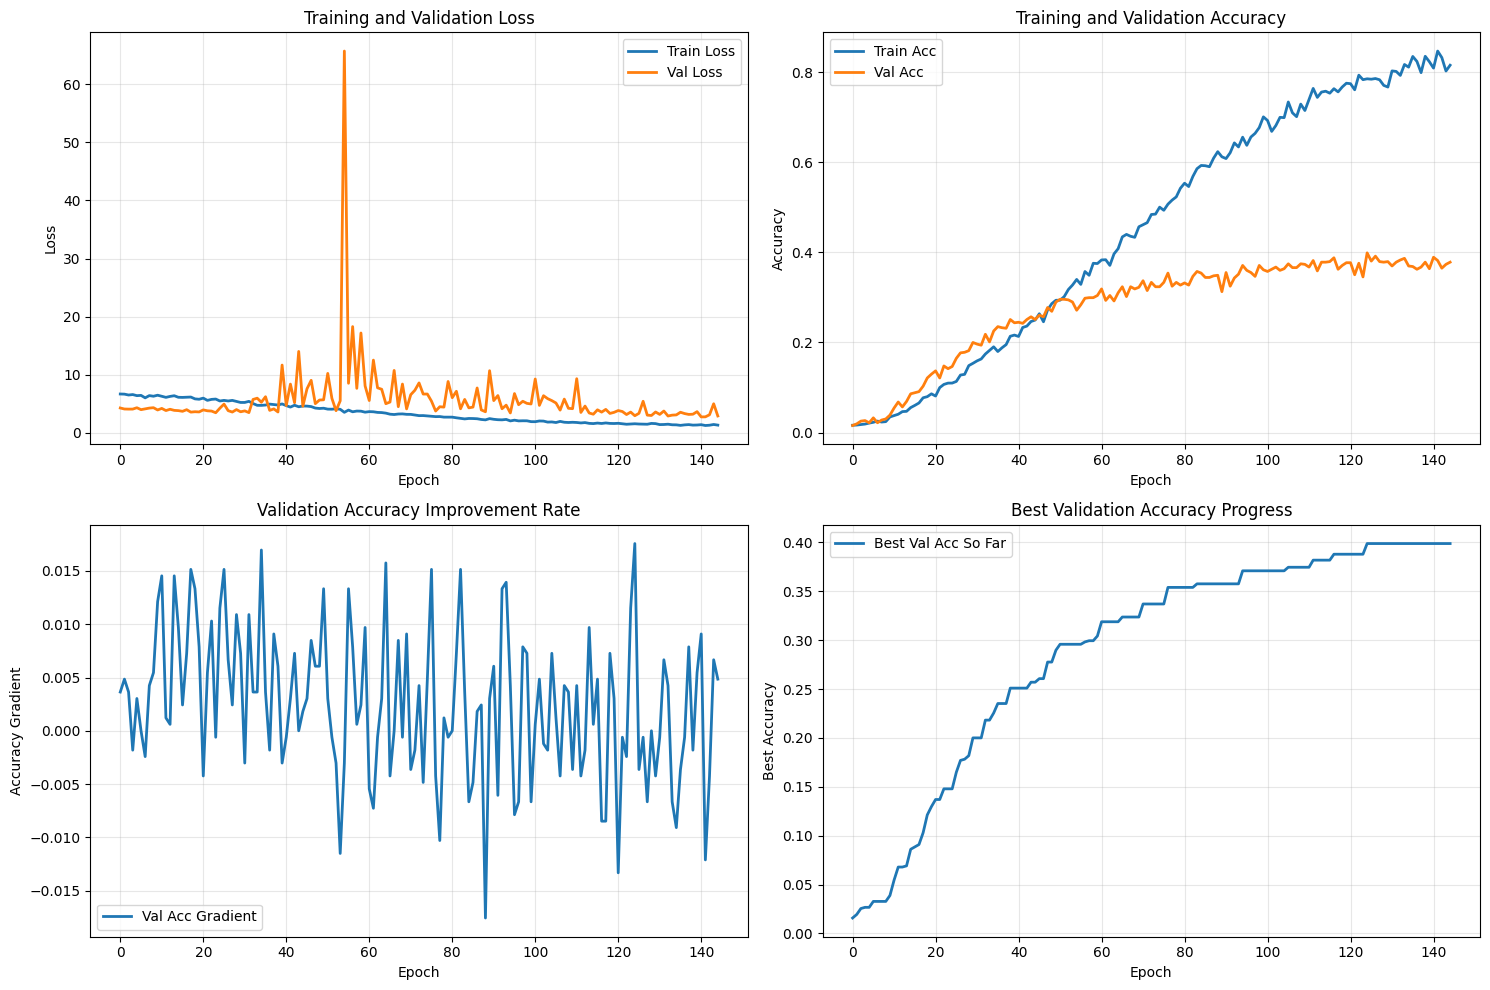


Final Results:
Best validation accuracy: 0.3988 (39.88%)
Test accuracy (no TTA): 0.3694 (36.94%)
Test accuracy (with TTA): 0.3694 (36.94%)
Improvement with TTA: 0.00%


In [10]:
# # ✅ Updated for faster training while keeping from-scratch setup

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torchvision import models
# from torch.optim.lr_scheduler import OneCycleLR

# # ✅ Simplified classifier
# class EnhancedModel(nn.Module):
#     def __init__(self, num_classes, model_name='efficientnet_b3'):
#         super(EnhancedModel, self).__init__()

#         if model_name == 'efficientnet_b3':
#             self.backbone = models.efficientnet_b3(weights=None)
#             num_features = self.backbone.classifier[1].in_features
#             self.backbone.classifier = nn.Identity()
#         elif model_name == 'resnet152':
#             self.backbone = models.resnet152(weights=None)
#             num_features = self.backbone.fc.in_features
#             self.backbone.fc = nn.Identity()
#         else:
#             self.backbone = models.resnet50(weights=None)
#             num_features = self.backbone.fc.in_features
#             self.backbone.fc = nn.Identity()

#         self.classifier = nn.Sequential(
#             nn.BatchNorm1d(num_features),
#             nn.Dropout(0.4),
#             nn.Linear(num_features, num_classes)
#         )

#     def forward(self, x):
#         features = self.backbone(x)
#         return self.classifier(features)

# # ✅ Use AMP always (skip condition check)
# scaler = torch.cuda.amp.GradScaler()

# # ✅ Mixed-precision + channels_last + compile for speed
# model = EnhancedModel(num_classes=67, model_name='efficientnet_b3')
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device, memory_format=torch.channels_last)
# model = torch.compile(model)

# # ✅ Optimizer
# optimizer = optim.AdamW([
#     {'params': model.backbone.parameters(), 'lr': 0.0001},
#     {'params': model.classifier.parameters(), 'lr': 0.001}
# ], weight_decay=0.01)

# # ✅ Scheduler
# scheduler = OneCycleLR(
#     optimizer,
#     max_lr=[0.001, 0.005],
#     steps_per_epoch=len(trainLoader),
#     epochs=100,
#     pct_start=0.1,
#     anneal_strategy='cos',
#     div_factor=25
# )

# # ✅ Training loop (AMP, compile, channels_last)
# def train_one_epoch():
#     model.train()
#     total_loss, correct, total = 0.0, 0, 0
#     for images, labels in trainLoader:
#         images = images.to(device, memory_format=torch.channels_last)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         with torch.cuda.amp.autocast():
#             outputs = model(images)
#             loss = criterion(outputs, labels)

#         scaler.scale(loss).backward()
#         scaler.unscale_(optimizer)
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         scaler.step(optimizer)
#         scaler.update()
#         scheduler.step()

#         total_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

#     return total_loss / len(trainLoader), correct / total

# # Continue using your validation and test loops unchanged
# # Just make sure images use `memory_format=torch.channels_last` and model is compiled
# loss, correct = train_one_epoch()
# print(f"Loss: {loss}, correct:{correct}")

# def train_model(model, train_loader, val_loader, num_epochs=100, patience=20):
#     train_losses, train_accs, val_losses, val_accs = [], [], [], []
#     best_val_acc = 0.0
#     patience_counter = 0
    
#     # Gradient scaler for mixed precision training
#     scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
#     for epoch in range(num_epochs):
#         # Training phase
#         model.train()
#         running_loss = 0.0
#         correct = 0
#         total = 0
        
#         progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
#         for batch_idx, (images, labels) in enumerate(progress_bar):
#             images, labels = images.to(device), labels.to(device)
            
#             # Apply mixup with probability 0.5
#             if random.random() > 0.5:
#                 images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
                
#                 optimizer.zero_grad()
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
#                     scaler.scale(loss).backward()
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                 else:
#                     outputs = model(images)
#                     loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     optimizer.step()
                
#                 # For accuracy calculation with mixup
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += labels.size(0)
#                 correct += (lam * predicted.eq(labels_a).sum().float() + 
#                            (1 - lam) * predicted.eq(labels_b).sum().float()).item()
#             else:
#                 optimizer.zero_grad()
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = criterion(outputs, labels)
#                     scaler.scale(loss).backward()
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels)
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                     optimizer.step()
                
#                 running_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()
            
#             running_loss += loss.item()
#             progress_bar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 
#                                     'Acc': f'{100.*correct/total:.2f}%'})
        
#         scheduler.step()
        
#         train_acc = correct / total
#         train_loss = running_loss / len(train_loader)
#         train_accs.append(train_acc)
#         train_losses.append(train_loss)
        
#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_correct = 0
#         val_total = 0
        
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
                
#                 if scaler:
#                     with torch.cuda.amp.autocast():
#                         outputs = model(images)
#                         loss = criterion(outputs, labels)
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels)
                
#                 val_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 val_total += labels.size(0)
#                 val_correct += (predicted == labels).sum().item()
        
#         val_acc = val_correct / val_total
#         val_loss = val_loss / len(val_loader)
#         val_accs.append(val_acc)
#         val_losses.append(val_loss)
        
#         print(f'Epoch [{epoch+1}/{num_epochs}] - '
#               f'Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | '
#               f'Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | '
#               f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
#         # Early stopping with model saving
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             patience_counter = 0
#             torch.save({
#                 'model_state_dict': model.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 'val_acc': val_acc,
#                 'epoch': epoch
#             }, 'best_model_enhanced.pth')
#             print(f"New best model saved with val acc: {val_acc:.4f}")
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 print(f"Early stopping at epoch {epoch+1}")
#                 break
    
#     return train_losses, train_accs, val_losses, val_accs

# # Test Time Augmentation
# def test_time_augmentation(model, image, num_augmentations=5):
#     """Apply test time augmentation for better predictions"""
#     augment_transforms = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((256, 256)),
#         transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#         transforms.RandomHorizontalFlip(p=0.5),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])
    
#     predictions = []
    
#     # Original prediction
#     with torch.no_grad():
#         pred = model(image.unsqueeze(0))
#         predictions.append(F.softmax(pred, dim=1))
    
#     # Augmented predictions
#     for _ in range(num_augmentations):
#         # Convert back to PIL for augmentation
#         pil_image = transforms.ToPILImage()(image.cpu())
#         aug_image = augment_transforms(pil_image).to(device)
        
#         with torch.no_grad():
#             pred = model(aug_image.unsqueeze(0))
#             predictions.append(F.softmax(pred, dim=1))
    
#     # Average all predictions
#     avg_pred = torch.mean(torch.stack(predictions), dim=0)
#     return avg_pred

# # Enhanced evaluation with TTA
# def evaluate_model_with_tta(model, test_loader, use_tta=True):
#     model.eval()
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_labels = []
    
#     with torch.no_grad():
#         for images, labels in tqdm(test_loader, desc="Evaluating"):
#             images, labels = images.to(device), labels.to(device)
            
#             if use_tta and images.size(0) == 1:  # TTA for single images
#                 outputs = test_time_augmentation(model, images[0])
#             else:
#                 outputs = model(images)
#                 outputs = F.softmax(outputs, dim=1)
            
#             _, predicted = torch.max(outputs, 1)
            
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
            
#             all_predictions.extend(predicted.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
    
#     accuracy = correct / total
#     return accuracy, all_predictions, all_labels
# num_epochs=200
# print("Starting enhanced training...")
# train_losses, train_accs, val_losses, val_accs = train_model(
#     model, trainLoader, valLoader, num_epochs=num_epochs, patience=20
# )

# # Load best model for testing
# checkpoint = torch.load('best_model_enhanced.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# print(f"Loaded best model from epoch {checkpoint['epoch']} with val acc: {checkpoint['val_acc']:.4f}")

# # Enhanced evaluation
# test_accuracy, predictions, true_labels = evaluate_model_with_tta(model, testLoader, use_tta=True)
# print(f'Test Accuracy with TTA: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# # Regular evaluation without TTA for comparison
# test_accuracy_no_tta, _, _ = evaluate_model_with_tta(model, testLoader, use_tta=False)
# print(f'Test Accuracy without TTA: {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)')

# # Detailed classification report
# class_names = testDataset.classes
# print("\nDetailed Classification Report:")
# print(classification_report(true_labels, predictions, target_names=class_names, digits=4, zero_division=0))

# # Plot enhanced training history
# plt.figure(figsize=(15, 10))

# plt.subplot(2, 2, 1)
# plt.plot(train_losses, label='Train Loss', linewidth=2)
# plt.plot(val_losses, label='Val Loss', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.title('Training and Validation Loss')
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 2)
# plt.plot(train_accs, label='Train Acc', linewidth=2)
# plt.plot(val_accs, label='Val Acc', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.title('Training and Validation Accuracy')
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 3)
# if len(val_accs) > 2:  # Need at least 3 points for gradient
#     plt.plot(np.gradient(val_accs), label='Val Acc Gradient', linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy Gradient')
#     plt.legend()
#     plt.title('Validation Accuracy Improvement Rate')
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'Not enough epochs\nfor gradient plot', 
#              ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Validation Accuracy Improvement Rate')

# plt.subplot(2, 2, 4)
# if len(val_accs) > 0:
#     epochs = range(len(val_accs))
#     plt.plot(epochs, [max(val_accs[:i+1]) for i in epochs], label='Best Val Acc So Far', linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Best Accuracy')
#     plt.legend()
#     plt.title('Best Validation Accuracy Progress')
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'No validation data\navailable', 
#              ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Best Validation Accuracy Progress')

# plt.tight_layout()
# plt.show()

# print(f"\nFinal Results:")
# print(f"Best validation accuracy: {max(val_accs):.4f} ({max(val_accs)*100:.2f}%)")
# print(f"Test accuracy (no TTA): {test_accuracy_no_tta:.4f} ({test_accuracy_no_tta*100:.2f}%)")
# print(f"Test accuracy (with TTA): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
# print(f"Improvement with TTA: {(test_accuracy - test_accuracy_no_tta)*100:.2f}%")

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from torchvision import models
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import random
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Download dataset
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
print('Data source import complete.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Setup paths
basePath = itsahmad_indoor_scenes_cvpr_2019_path
imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
trainLabelFile = os.path.join(basePath, "TrainImages.txt")
testLabelFile = os.path.join(basePath, "TestImages.txt")

class Indoor67Dataset(Dataset):
    def __init__(self, imgDir, image_list, transform=None):
        self.samples = []
        self.transform = transform
        
        for imgName in image_list:
            if imgName.strip():
                label = imgName.split('/')[0]
                fullPath = os.path.join(imgDir, imgName)
                if os.path.isfile(fullPath):
                    self.samples.append((fullPath, label))
        
        self.classes = sorted(set(lbl for _, lbl in self.samples))
        self.classToIdx = {cls: i for i, cls in enumerate(self.classes)}
        print(f"Loaded {len(self.samples)} samples with {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, self.classToIdx[label]
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            # Return a dummy image if loading fails
            dummy_image = torch.zeros(3, 224, 224)
            return dummy_image, self.classToIdx[label]

# Enhanced data augmentation
trainTransform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.RandomApply([transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3))  # Cutout augmentation
])

# Test Time Augmentation transforms
valTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

testTransform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets
trainDataset = Indoor67Dataset(imgDir, train_list, transform=trainTransform)
valDataset = Indoor67Dataset(imgDir, val_list, transform=valTransform)

# For test, read from file
with open(testLabelFile, 'r') as f:
    test_list = f.read().splitlines()
testDataset = Indoor67Dataset(imgDir, test_list, transform=testTransform)
# lr_backbone': 0.0001, 'lr_classifier': 0.001, 'dropout1': 0.5, 'dropout2': 0.4, 'batch_size': 32
batch_size=32
# Optimized data loading
trainLoader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
valLoader = DataLoader(valDataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testLoader = DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class EnhancedModel(nn.Module):
    def __init__(self, num_classes, model_name='efficientnet_b3', dropout_rate=0.3):
        super(EnhancedModel, self).__init__()
        if model_name == 'efficientnet_b3':
            self.backbone = models.efficientnet_b3(weights=None)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        elif model_name == 'resnet152':
            self.backbone = models.resnet152(weights=None)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else:
            self.backbone = models.resnet50(weights=None)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            
        # Enhanced classifier with more regularization
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(num_features),
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, num_features // 2),  # Add intermediate layer
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(num_features // 2),
            nn.Dropout(dropout_rate * 0.5),  # Less dropout in deeper layers
            nn.Linear(num_features // 2, num_classes)
        )
        
        # Initialize weights properly
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# Early stopping class
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_score, model):
        score = val_score
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
                return True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

# Improved setup
def setup_training(num_classes=67, model_name='efficientnet_b3'):
    # Model setup
    model = EnhancedModel(num_classes=num_classes, model_name=model_name, dropout_rate=0.3)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device, memory_format=torch.channels_last)
    model = torch.compile(model)
    
    # Improved optimizer with different learning rates
    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': 3e-4, 'weight_decay': 1e-4},  # Higher LR for backbone
        {'params': model.classifier.parameters(), 'lr': 1e-3, 'weight_decay': 1e-3}  # Higher LR for classifier
    ])
    
    # Alternative scheduler - Cosine Annealing with warm restarts
    scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
    
    # Label smoothing loss for better generalization
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # AMP scaler
    scaler = torch.cuda.amp.GradScaler()
    
    # Early stopping
    early_stopping = EarlyStopping(patience=15, min_delta=0.005)
    
    return model, optimizer, scheduler, criterion, scaler, early_stopping, device

# Improved training function
def train_one_epoch(model, trainLoader, optimizer, criterion, scaler, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(trainLoader):
        images = images.to(device, memory_format=torch.channels_last, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Gradient scaling and clipping
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        # Update metrics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Step scheduler after epoch (not after each batch for CosineAnnealingLR)
    scheduler.step()
    
    return total_loss / len(trainLoader), correct / total

# Validation function
def validate(model, valLoader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in valLoader:
            images = images.to(device, memory_format=torch.channels_last, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(valLoader), correct / total

# Training loop with early stopping
def train_model(model, trainLoader, valLoader, optimizer, criterion, scaler, scheduler, early_stopping, device, epochs=100):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    for epoch in range(epochs):
        # Training
        train_loss, train_acc = train_one_epoch(model, trainLoader, optimizer, criterion, scaler, scheduler, device)
        
        # Validation
        val_loss, val_acc = validate(model, valLoader, criterion, device)
        
        # Store metrics
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Print progress
        current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | '
              f'Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | LR: {current_lr:.6f}')
        
        # Early stopping check
        if early_stopping(val_acc, model):
            print(f'Early stopping triggered at epoch {epoch+1}')
            break
    
    return train_losses, train_accs, val_losses, val_accs

# Usage example
if __name__ == "__main__":
    # Setup
    model, optimizer, scheduler, criterion, scaler, early_stopping, device = setup_training()
    
    # Assuming you have trainLoader and valLoader defined
    train_losses, train_accs, val_losses, val_accs = train_model(
        model, trainLoader, valLoader, optimizer, criterion, scaler, scheduler, early_stopping, device
    )
    
    print("Setup complete. Key improvements:")
    print("1. Higher learning rates with proper weight decay")
    print("2. Enhanced classifier with intermediate layer")
    print("3. Label smoothing for better generalization")
    print("4. Early stopping to prevent overfitting")
    print("5. Proper weight initialization")
    print("6. CosineAnnealingLR scheduler for better convergence")

Data source import complete.
Using device: cuda


NameError: name 'train_list' is not defined